***EXP-6***
# *23A91A0459*
***S.Nikhil Prince***

In [ ]:
# Import necessary libraries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
# To remove warning messages from the output
import warnings
warnings.simplefilter(action = 'ignore')

## Reading Dataset

In [ ]:
# Loading the dataset
df = pd.read_csv('/content/heart-1.csv')

# Exploring the data

In [ ]:
# Displaying the first 5 rows of the DataFrame
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Displaying the last 5 rows of the DataFrame
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
# Displaying the shape of the dataset (#columns, #rows)
df.shape

(1025, 14)

In [ ]:
# Displaying the general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# Displaying the statistical information about the features of the dataset
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


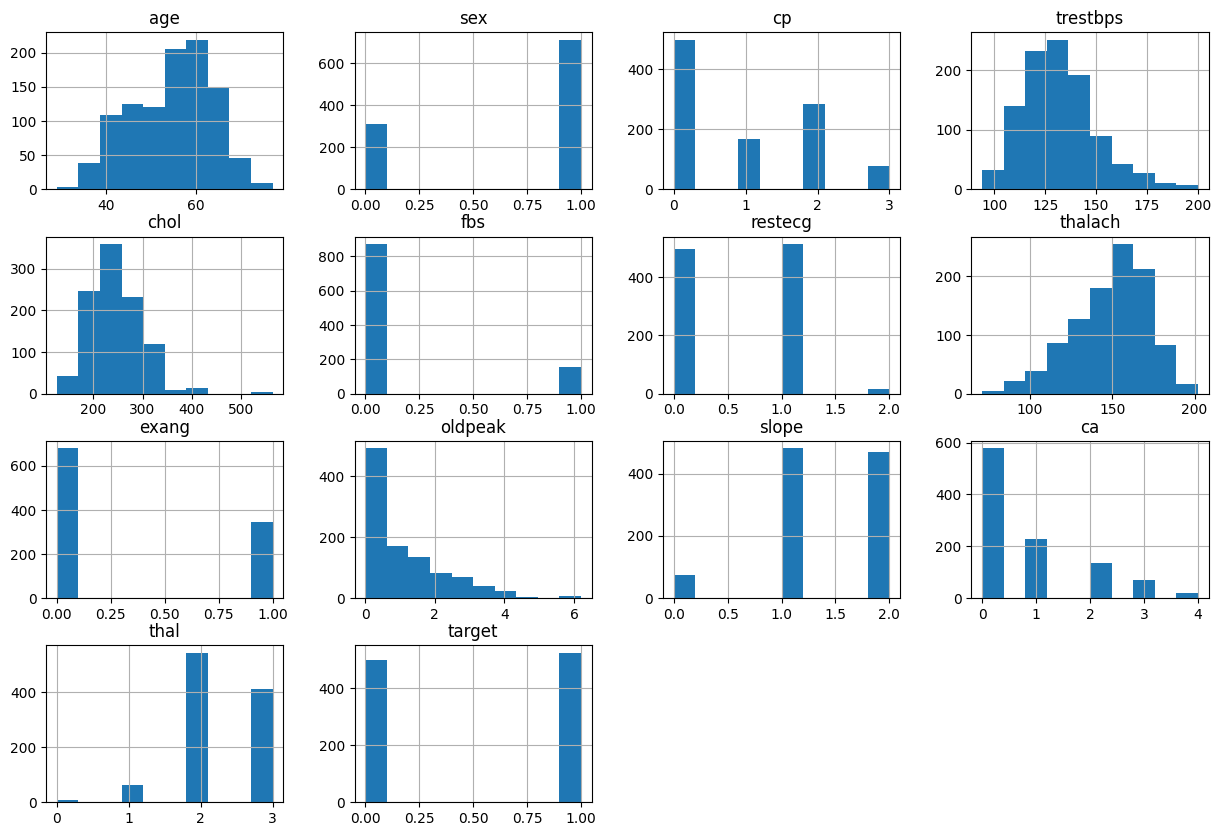

In [ ]:
# Displaying the histogram of the features of the dataset
df.hist(figsize=(15, 10));

In [ ]:
# Displaying unique values of the dataset features
df.nunique()

,0
age,41
sex,2
cp,4
trestbps,49
chol,152
fbs,2
restecg,3
thalach,91
exang,2
oldpeak,40


In [ ]:
# Displaying missing values count, if any.
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Displaying the output variable lables count
target_count = df['target'].value_counts()
print(target_count)

target
1    526
0    499
Name: count, dtype: int64


## Data Splitting




In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Random state ensures that the same train–test split is produced every time you run the code.

## Fitting the model
(Model training)



In [ ]:
# Creating an instance of the Logistic Regression model from the scikit-learn library.
log_reg_model = LogisticRegression()

# Training the model using training data
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model has been trained successfully")

Logistic Regression model has been trained successfully


## Model Predictions



In [ ]:
# Predicting the labels on testing data
y_pred = log_reg_model.predict(X_test)
print("Predictions on test data generated successfully")

Predictions on test data generated successfully


## Evaluating the Model



In [ ]:
# Evaluating the performance of the logistic regression model

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[70 32]
 [13 90]]

Accuracy: 0.7804878048780488

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.69      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.78       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.78      0.78       205



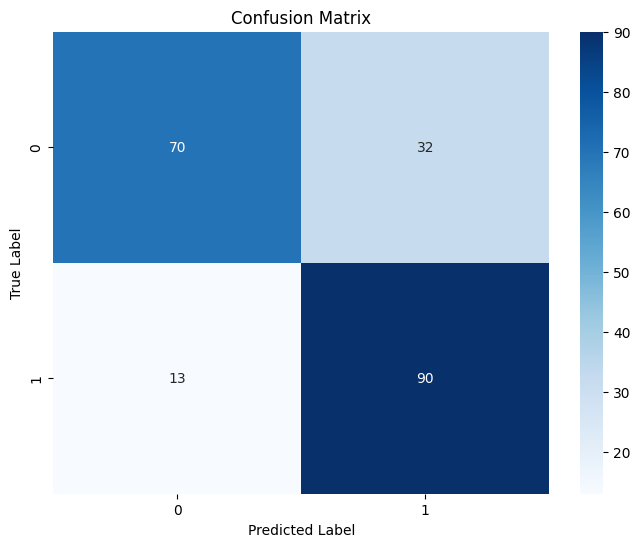

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True,  cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

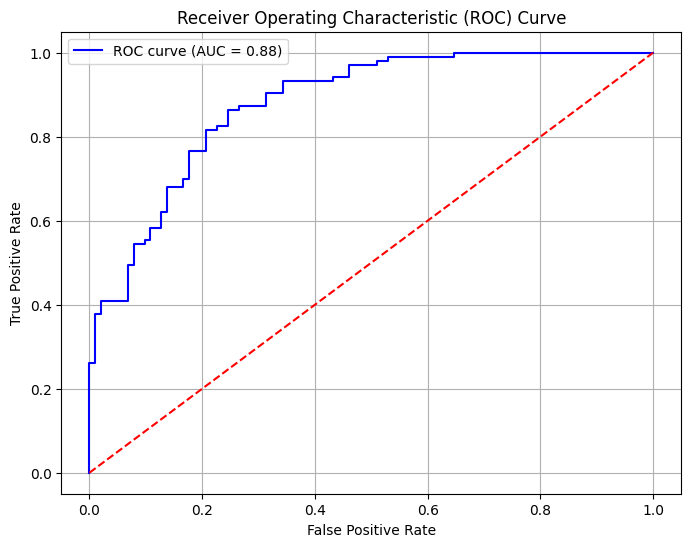

In [ ]:
# Get predicted probabilities for the positive class
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
# FPR is the proportion of actual negative cases were incorrectly classified as positive.
# TPR is the proportion of actual positive cases were correctly identified as positive.

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Performance on Training set
y_pred_train = log_reg_model.predict(X_train)
conf_matrix = confusion_matrix(y_train, y_pred_train)
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train))
print("\nAccuracy:", accuracy_score(y_train, y_pred_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))


Confusion Matrix:
 [[321  76]
 [ 40 383]]

Accuracy: 0.8585365853658536

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.81      0.85       397
           1       0.83      0.91      0.87       423

    accuracy                           0.86       820
   macro avg       0.86      0.86      0.86       820
weighted avg       0.86      0.86      0.86       820



In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Fitting the Naive Bayes model

In [ ]:
# Creating an instance of the Naive Bayes model from the scikit-learn library.
nb = GaussianNB()
# Training the model using training data
nb.fit(X_train, y_train)
print("Naive Bayes model has been trained successfully")


Naive Bayes model has been trained successfully


# Naive Bayes Model Predictions

In [ ]:
# Predicting the labels on testing data
y_pred_nb = nb.predict(X_test)
print("Predictions on test data generated successfully")

Predictions on test data generated successfully


# Evaluating the Model

In [ ]:
# Evaluating the performance of the logistic regression modelprint("\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb))


Accuracy: 0.8
=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       102
           1       0.75      0.89      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



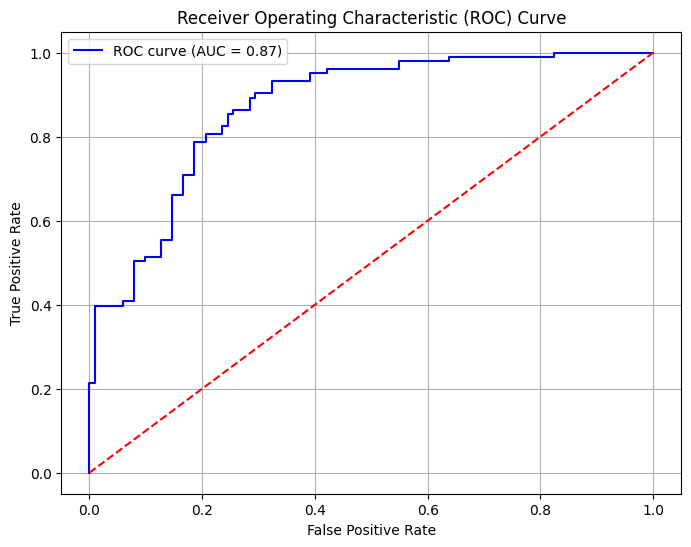

In [ ]:
# Get predicted probabilities for the positive class
y_pred_proba_nb = nb.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_nb)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_nb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

# Feature Scaling (for KNN & SVM)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# KNN Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Creating an instance of the KNN model from the scikit-learn library.
knn = KNeighborsClassifier(n_neighbors=5)

# Training the model using training data
# Ensure you have run cell wVp9gRqc987G to define X_train_scaled
knn.fit(X_train_scaled, y_train)
print("KNN model has been trained successfully")

KNN model has been trained successfully


# KNN Mdoel Predictions

In [ ]:
# Predicting the labels on testing data
y_pred_knn = knn.predict(X_test_scaled)
print("Predictions on test data generated successfully")

Predictions on test data generated successfully


# Evaluating the Model

In [ ]:
# Evaluating the performance of the logistic regression model
print("\nAccuracy:", accuracy_score(y_test, y_pred_knn))
print("=== KNN Classification Report ===")
print(classification_report(y_test, y_pred_knn))


Accuracy: 0.8341463414634146
=== KNN Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



KNN ROC-AUC Score: 0.9485532076908434


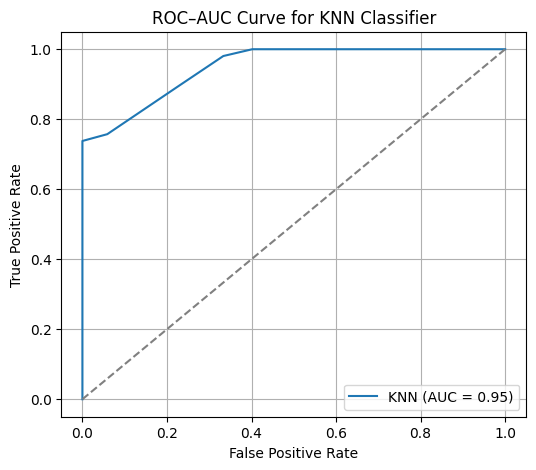

In [ ]:
# Get probability scores for the positive class
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

# Calculate ROC-AUC score
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("KNN ROC-AUC Score:", auc_knn)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve for KNN Classifier")
plt.legend()
plt.grid(True)
plt.show()


# Decision Tree Model

In [ ]:
# Creating an instance of the KNN model from the scikit-learn library.
dt = DecisionTreeClassifier(random_state=42)
# Training the model using training data
dt.fit(X_train, y_train)
print("Decision Tree model has been trained successfully")

Decision Tree model has been trained successfully


# Decision Tree Model Predictions

In [ ]:
# Predicting the labels on testing data
y_pred_dt = dt.predict(X_test)
print("Predictions on test data generated successfully")

Predictions on test data generated successfully


# Evaluating the Model

In [ ]:
# Evaluating the performance of the logistic regression model
print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("=== Decision Tree Classification Report ===")
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.9853658536585366
=== Decision Tree Classification Report ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



Decision Tree ROC-AUC Score: 0.9854368932038835


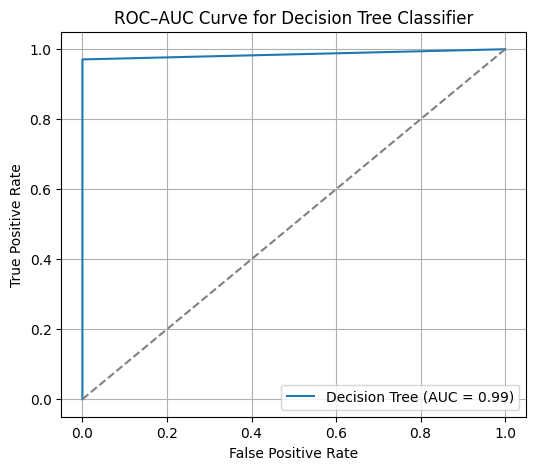

In [ ]:
# Get probability scores for the positive class
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# Calculate ROC-AUC score
auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC Score:", auc_dt)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve for Decision Tree Classifier")
plt.legend()
plt.grid(True)
plt.show()


# SVM Model

In [ ]:
# Creating an instance of the SVM model from the scikit-learn library.
svm = SVC(kernel='rbf', probability=True, random_state=42)
# Training the model using training data
svm.fit(X_train_scaled, y_train)
print("SVM model has been trained successfully")


SVM model has been trained successfully


# SVM Model Predictions

In [ ]:
# Predicting the labels on testing data
y_pred_svm = svm.predict(X_test_scaled)
print("Predictions on test data generated successfully")

Predictions on test data generated successfully


# Evaluating the Model

In [ ]:
# Evaluating the performance of the logistic regression model
print("\nAccuracy:", accuracy_score(y_test, y_pred_svm))
print("=== SVM Classification Report ===")
print(classification_report(y_test, y_pred_svm))


Accuracy: 0.8878048780487805
=== SVM Classification Report ===
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205



SVM ROC-AUC Score: 0.9631639063392347


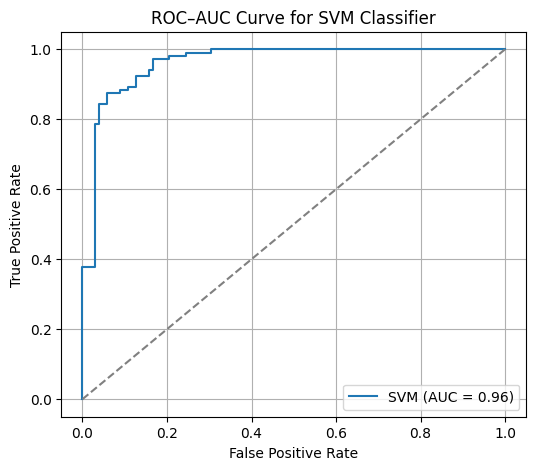

In [ ]:
# Get probability scores for the positive class
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

# Calculate ROC-AUC score
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM ROC-AUC Score:", auc_svm)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')  # Random classifier
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve for SVM Classifier")
plt.legend()
plt.grid(True)
plt.show()


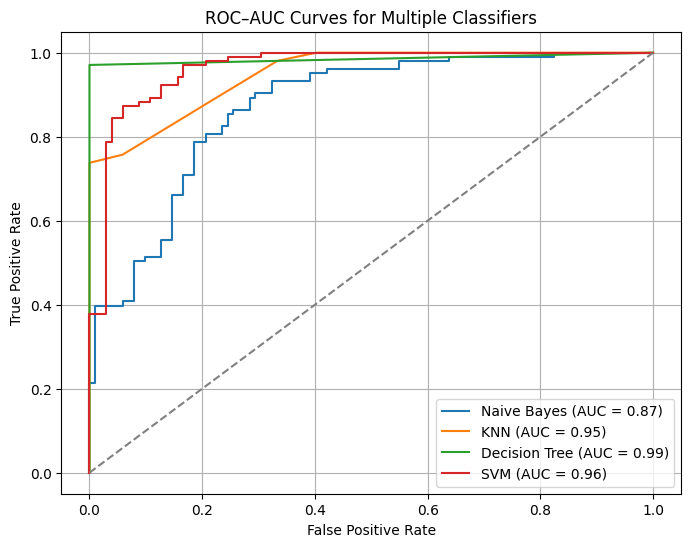

In [ ]:
plt.figure(figsize=(8,6))

# -------- Naive Bayes --------
y_prob_nb = nb.predict_proba(X_test)[:,1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = roc_auc_score(y_test, y_prob_nb)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.2f})")

# -------- KNN --------
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")

# -------- Decision Tree --------
y_prob_dt = dt.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.2f})")

# -------- SVM --------
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")

# Random classifier line
plt.plot([0,1], [0,1], '--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curves for Multiple Classifiers")
plt.legend()
plt.grid(True)
plt.show()
